### 第 1 个输出端口的纯净复振幅表达式 $E_{out}(1)$ :

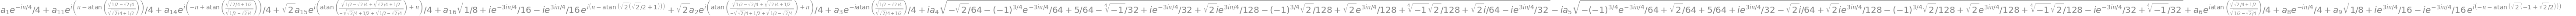

In [5]:
import sympy as sp
from IPython.display import display, Markdown

# 1. 开启 Jupyter 的高级数学公式渲染 (关键步骤)
sp.init_printing()

# =========================================================
# 2. 初始化符号与参数
# =========================================================
N_sub = 8
N_total = 16

# 生成输入变量 a1 到 a16
a_vars = sp.symbols('a1:17')
a = sp.Matrix(a_vars)

# =========================================================
# 3. 生成精确的 8x8 MMI 传输矩阵
# =========================================================
T8_elements = []
for j in range(1, N_sub + 1):
    row = []
    for i in range(1, N_sub + 1):
        if (i + j) % 2 == 0:
            coeff = 1 + sp.Rational((j - i) * (2 * N_sub - j + i), 4 * N_sub)
        else:
            coeff = sp.Rational((j + i - 1) * (2 * N_sub - j - i + 1), 4 * N_sub)
        
        val = sp.exp(sp.I * coeff * sp.pi)
        row.append(val)
    T8_elements.append(row)

T8 = sp.Matrix(T8_elements)
T8 = T8[:, ::-1] # 坐标系变换：自下而上 -> 自上而下 (翻转列)
T8 = (1 / sp.sqrt(N_sub)) * T8 # 乘上功率均分系数

# =========================================================
# 4. 组装 16x16 级联系统矩阵
# =========================================================
S1 = sp.diag(T8, T8)
S2 = sp.diag(T8, T8)

W = sp.zeros(N_total, N_total)
W[0:4, 0:4]     = sp.eye(4)  
W[8:12, 4:8]    = sp.eye(4)  
W[4:8, 8:12]    = sp.eye(4)  
W[12:16, 12:16] = sp.eye(4)  

# =========================================================
# 5. 计算干涉并提取干净的指数形式
# =========================================================
T16_raw = S2 * W * S1
T16_clean = sp.zeros(N_total, N_total)

for row in range(N_total):
    for col in range(N_total):
        val = sp.simplify(T16_raw[row, col])
        if val != 0:
            r = sp.Abs(val)
            theta = sp.arg(val)
            T16_clean[row, col] = r * sp.exp(sp.I * theta)

# =========================================================
# 6. 计算输出并在 Jupyter 中优雅地显示
# =========================================================
E_out = T16_clean * a

display(Markdown("### 第 1 个输出端口的纯净复振幅表达式 $E_{out}(1)$ :"))
# 在 Jupyter 中，直接使用 display() 即可触发完美的 LaTeX 渲染
display(E_out[0])

In [6]:
import numpy as np
import sympy as sp
from IPython.display import display, Markdown

# 开启 Jupyter 数学公式渲染
sp.init_printing()

N_sub = 8
N_total = 16

# =========================================================
# 1. 纯数值计算：让 Numpy 在底层完美处理复数干涉加法
# =========================================================
# 这里的计算没有任何代数包袱，绝对精确抵消
Phi = np.zeros((N_sub, N_sub))
for j in range(1, N_sub + 1):
    for i in range(1, N_sub + 1):
        if (i + j) % 2 == 0:
            Phi[j-1, i-1] = np.pi + (np.pi / (4 * N_sub)) * (j - i) * (2 * N_sub - j + i)
        else:
            Phi[j-1, i-1] = (np.pi / (4 * N_sub)) * (j + i - 1) * (2 * N_sub - j - i + 1)

Phi_wrapped = np.angle(np.exp(1j * Phi))
Phi_new = np.fliplr(Phi_wrapped) # 翻转列，变成自上而下

# 8x8 数值传输矩阵
T8_num = (1 / np.sqrt(N_sub)) * np.exp(1j * Phi_new)

# 组装 16x16 矩阵
Z = np.zeros((8, 8))
S1 = np.block([[T8_num, Z], [Z, T8_num]])
S2 = np.block([[T8_num, Z], [Z, T8_num]])

W = np.zeros((16, 16))
W[0:4, 0:4]     = np.eye(4)  
W[8:12, 4:8]    = np.eye(4)  
W[4:8, 8:12]    = np.eye(4)  
W[12:16, 12:16] = np.eye(4)  

# 完成所有路径的光场干涉相加，得到数值结果矩阵
T16_num = S2 @ W @ S1

# =========================================================
# 2. 符号逆向重建：把干净的数值重新穿上代数的外衣
# =========================================================
a = sp.Matrix(sp.symbols('a1:17'))
E_out_clean = sp.zeros(N_total, 1)

for row in range(N_total):
    expr = sp.sympify(0)
    for col in range(N_total):
        val = T16_num[row, col]
        
        # 过滤掉 1e-15 级别的数值计算误差
        if np.abs(val) > 1e-10:
            
            # 核心技巧1：对幅度平方，然后用 nsimplify 猜出绝对精确的分数（例如 0.125 -> 1/8）
            mag2 = sp.nsimplify(np.abs(val)**2, tolerance=1e-5, rational=True)
            mag = sp.sqrt(mag2)
            
            # 核心技巧2：提取相位除以 pi，同样还原为精确的分数
            ph_frac = sp.nsimplify(np.angle(val) / np.pi, tolerance=1e-5, rational=True)
            
            # 重新组装成纯指数项
            if ph_frac == 0:
                term = mag * a[col]
            else:
                term = mag * sp.exp(sp.I * ph_frac * sp.pi) * a[col]
                
            expr += term
            
    E_out_clean[row] = expr

# =========================================================
# 3. 输出结果
# =========================================================
display(Markdown("### 第 1 个输出端口的【极简解析解】 $E_{out}(1)$ :"))
display(E_out_clean[0])

### 第 1 个输出端口的【极简解析解】 $E_{out}(1)$ :

In [32]:
import numpy as np
import sympy as sp
from IPython.display import display, Markdown, Latex

# =========================================================
# 16×16 Cross-MMI：计算第 1 个输出端口响应 E_out(1)
# 输入：a1 ... a16
# 单个 8×8 MMI 相位关系来自图2（Eq. 2-24），取均匀分光（1/sqrt(8)）
# =========================================================

N_sub = 8
N_total = 16
phi0 = 0.0  # 相位常数（弧度），若论文给定可在此修改

# ---------------------------------------------------------
# 1) 构造单个 8×8 MMI 传输矩阵（数值版）
#    论文中 i 为输入编号（自下而上），j 为输出编号（自上而下）。
#    我们用矩阵列对应输入端口（自上而下），所以需要对列做翻转（fliplr）。
# ---------------------------------------------------------
DEN = 4 * N_sub  # N=8 -> 32，所有相位都是 π/DEN 的整数倍
m = np.zeros((N_sub, N_sub), dtype=int)
for j in range(1, N_sub + 1):        # 输出：自上而下
    for i in range(1, N_sub + 1):    # 输入：论文中自下而上
        if (i + j) % 2 == 0:
            m[j - 1, i - 1] = DEN + (j - i) * (2 * N_sub - j + i)
        else:
            m[j - 1, i - 1] = (j + i - 1) * (2 * N_sub - j - i + 1)

Phi = (np.pi / DEN) * m + phi0
Phi = np.fliplr(Phi)  # 把输入端口编号转换成自上而下
T8_num = (1 / np.sqrt(N_sub)) * np.exp(1j * Phi)

# ---------------------------------------------------------
# 2) 组装 16×16 网络：左右各两个 8×8 MMI，中间为“4 路交叉”置换矩阵 W
#    端口约定：
#      输入 a1..a8  -> 左上 8×8 MMI（自上而下）
#      输入 a9..a16 -> 左下 8×8 MMI（自上而下）
#      输出 1..8    -> 右上 8×8 MMI（自上而下）
#      输出 9..16   -> 右下 8×8 MMI（自上而下）
# ---------------------------------------------------------
Z8 = np.zeros((8, 8), dtype=complex)
S = np.block([[T8_num, Z8], [Z8, T8_num]])

# 中间连线：外侧 4 路直通，中间 4 路上下互换（与示意图一致）
W = np.zeros((16, 16), dtype=complex)
W[0:4, 0:4]     = np.eye(4)
W[4:8, 8:12]    = np.eye(4)
W[8:12, 4:8]    = np.eye(4)
W[12:16, 12:16] = np.eye(4)

T16_num = S @ W @ S

# ---------------------------------------------------------
# 3) 把数值系数“量化”为干净的解析形式：
#    - 幅度平方 |c|^2 量化为分母为 2^k 的有理数（避免 nsimplify 猜出怪分母）
#    - 相位 angle(c)/π 量化为分母 32 的有理数（因为单级 MMI 相位就是 π/32 的整数倍）
# ---------------------------------------------------------
a = sp.Matrix(sp.symbols('a1:17'))

def quantize_coeff(val, *, mag2_den=256, phase_den=32, tol=1e-10):
    if abs(val) < tol:
        return sp.Integer(0)

    mag2_num = int(np.round((abs(val) ** 2) * mag2_den))
    if mag2_num == 0:
        return sp.Integer(0)
    mag2 = sp.Rational(mag2_num, mag2_den)
    mag = sp.sqrt(mag2)

    ph_num = int(np.round((np.angle(val) / np.pi) * phase_den))
    ph = sp.Rational(ph_num, phase_den)

    if ph == 0:
        return mag
    # 不在这里 simplify：避免 exp(I*pi*r) 被自动改写成 (-1)**r
    return mag * sp.exp(sp.I * sp.pi * ph)

def pow_minus_one_to_exp(expr):
    return sp.sympify(expr).replace(
        lambda x: isinstance(x, sp.Pow) and x.base == -1 and x.exp.is_Rational,
        lambda x: sp.exp(sp.I * sp.pi * x.exp),
    )

E_out_1 = sp.sympify(0)
for k in range(N_total):
    c = quantize_coeff(T16_num[0, k])
    if c != 0:
        E_out_1 += c * a[k]

E_out_1 = sp.simplify(E_out_1)
E_out_1_exp = sp.expand(pow_minus_one_to_exp(E_out_1))

# ---------------------------------------------------------
# 4) 严格按 a1..a16 数值升序展示
#    说明：Sympy 的默认 pretty/LaTeX 打印会按字典序重排（a10 会跑到 a2 前），
#          所以这里用“手工拼接 LaTeX”的方式保证输出顺序。
# ---------------------------------------------------------
latex_terms = []
for k in range(N_total):
    ck = pow_minus_one_to_exp(E_out_1_exp.coeff(a[k]))
    if ck != 0:
        latex_terms.append(f"{sp.latex(a[k])}\\left({sp.latex(ck, order='none')}\\right)")

E_out_1_ordered_latex = " + ".join(latex_terms) if latex_terms else "0"

display(Markdown("### 16×16 结构第 1 个输出端口响应 $E_{out}(1)$（输入 $a_1\\ldots a_{16}$）"))
display(Latex(r"$E_{out}(1) = " + E_out_1_ordered_latex + r"$"))

### 16×16 结构第 1 个输出端口响应 $E_{out}(1)$（输入 $a_1\ldots a_{16}$）

<IPython.core.display.Latex object>

In [23]:
import sympy as sp
import numpy as np

expr = E_out_1_exp

def pow_minus_one_to_exp_local(e):
    return e.replace(
        lambda x: isinstance(x, sp.Pow) and x.base == -1,
        lambda x: sp.exp(sp.I * sp.pi * x.exp),
    )

# 逐个提取 a1..a16 的系数（按端口编号顺序）
# 注意：这里刻意不做 simplify，避免把“负号”吸收到相位里，确保与展示式逐项一致。
coeffs = [pow_minus_one_to_exp_local(expr.coeff(a[i])) for i in range(N_total)]

print("Nonzero coefficients (a1..a16), consistent with the displayed expression:")
for idx, c in enumerate(coeffs, start=1):
    if c != 0:
        print(f"a{idx}: {sp.sstr(c)}")

# 手工拼接 LaTeX，保证严格按 a1..a16 数值升序输出（避免 a10 跑到 a2 前）
latex_terms = []
for i, c in enumerate(coeffs):
    if c != 0:
        latex_terms.append(f"{sp.latex(a[i])}\\left({sp.latex(c, order='none')}\\right)")

latex_ordered = " + ".join(latex_terms) if latex_terms else "0"

print("\nLaTeX (copyable, ordered a1..a16):")
print(r"E_{out}(1) = " + latex_ordered)

# sanity check: 幺正行应满足 sum |coeff|^2 = 1
row0 = T16_num[0, :]
print("\nSum |row0|^2 =", float(np.sum(np.abs(row0) ** 2)))

# =========================================================
# Trace: 追踪 a7（输入端口7）为什么在输出端口1系数为 0
# =========================================================

k = 6   # a7 的 0-based 列索引
out = 0 # 输出端口1 的 0-based 行索引

c_direct = T16_num[out, k]
print("\n--- Trace a7 -> output1 (numerical) ---")
print("T16_num[1,7] =", c_direct)

# 根据结构 T16 = S @ W @ S：对输出1而言，S[out, p] 只在 p=1..8 非零。
# 又因为 W 把 p=5..8 映射到 q=9..12，而 S[q,7]=0（a7 属于上半块输入），
# 所以只有 p=1..4 这 4 条路径会贡献到 output1。
terms = []
for p in range(4):  # p=0..3 对应中间端口1..4
    term = T8_num[out, p] * T8_num[p, k]
    terms.append(term)
    mag = np.abs(term)
    ph_pi = np.angle(term) / np.pi
    print(f"via mid port {p+1}: term={term}, |term|={mag:.6g}, phase/pi={ph_pi:.6g}")

sum_terms = sum(terms)
print("sum(4 terms) =", sum_terms)
print("|sum| =", float(np.abs(sum_terms)), ", phase/pi =", float(np.angle(sum_terms) / np.pi))

# 能量不会丢：看 a7 单独激励时，输出功率主要落在哪些端口
col = T16_num[:, k]
powers = np.abs(col) ** 2
print("\n--- Where does a7 power go? (top outputs) ---")
idxs = np.argsort(-powers)
for n in range(8):
    o = int(idxs[n])
    print(f"out{o+1}: power={powers[o]:.6g}, coeff={col[o]}")
print("sum power =", float(np.sum(powers)))


Nonzero coefficients (a1..a16), consistent with the displayed expression:
a1: -exp(3*I*pi/4)/4
a2: sqrt(2)*I*exp(I*pi/8)/4
a3: -exp(7*I*pi/8)/4
a4: I/4
a5: -I/4
a6: -exp(-5*I*pi/8)/4
a8: -exp(3*I*pi/4)/4
a9: -3*exp(I*pi/8)/16
a11: -exp(-I*pi/8)/4
a14: -exp(3*I*pi/8)/4
a15: sqrt(2)*I*exp(I*pi/8)/4
a16: sqrt(55)*I*exp(I*pi/8)/16

LaTeX (copyable, ordered a1..a16):
E_{out}(1) = a_{1}\left(- \frac{e^{\frac{3 \pi i}{4}}}{4}\right) + a_{2}\left(\frac{i \sqrt{2} e^{\frac{\pi i}{8}}}{4}\right) + a_{3}\left(- \frac{e^{\frac{7 \pi i}{8}}}{4}\right) + a_{4}\left(\frac{i}{4}\right) + a_{5}\left(- \frac{i}{4}\right) + a_{6}\left(- \frac{e^{- \frac{5 \pi i}{8}}}{4}\right) + a_{8}\left(- \frac{e^{\frac{3 \pi i}{4}}}{4}\right) + a_{9}\left(- \frac{3 e^{\frac{\pi i}{8}}}{16}\right) + a_{11}\left(- \frac{e^{- \frac{\pi i}{8}}}{4}\right) + a_{14}\left(- \frac{e^{\frac{3 \pi i}{8}}}{4}\right) + a_{15}\left(\frac{i \sqrt{2} e^{\frac{\pi i}{8}}}{4}\right) + a_{16}\left(\frac{i \sqrt{55} e^{\frac{\pi i}{8}}}

In [31]:
import numpy as np

# =========================================================
# Zero-pattern: 每个输出端口“缺失”的输入项（|系数|≈0）
# =========================================================

tol = 1e-10
zeros_per_row = []
zeros_per_col = []

print(f"Tolerance = {tol:g}\n")

print("--- Missing inputs per output (row-wise) ---")
for r in range(N_total):
    miss = [k + 1 for k in range(N_total) if abs(T16_num[r, k]) < tol]
    zeros_per_row.append(len(miss))
    print(f"out{r+1:2d}: missing {len(miss):2d} -> {miss}")

print("\n--- Missing outputs per input (col-wise) ---")
for k in range(N_total):
    miss = [r + 1 for r in range(N_total) if abs(T16_num[r, k]) < tol]
    zeros_per_col.append(len(miss))
    print(f"in {k+1:2d}: missing {len(miss):2d} -> {miss}")

print("\nSummary:")
print("zeros per row  :", sorted(set(zeros_per_row)), "(min=", min(zeros_per_row), ", max=", max(zeros_per_row), ")")
print("zeros per col  :", sorted(set(zeros_per_col)), "(min=", min(zeros_per_col), ", max=", max(zeros_per_col), ")")
print("total zeros    :", int(np.sum(np.abs(T16_num) < tol)))
print("matrix size    :", N_total * N_total)
print("sparsity (zero):", float(np.mean(np.abs(T16_num) < tol)))


Tolerance = 1e-10

--- Missing inputs per output (row-wise) ---
out 1: missing  4 -> [7, 10, 12, 13]
out 2: missing  4 -> [8, 9, 11, 14]
out 3: missing  4 -> [5, 10, 12, 15]
out 4: missing  4 -> [6, 9, 11, 16]
out 5: missing  4 -> [3, 9, 14, 16]
out 6: missing  4 -> [4, 10, 13, 15]
out 7: missing  4 -> [1, 11, 14, 16]
out 8: missing  4 -> [2, 12, 13, 15]
out 9: missing  4 -> [2, 4, 5, 15]
out10: missing  4 -> [1, 3, 6, 16]
out11: missing  4 -> [2, 4, 7, 13]
out12: missing  4 -> [1, 3, 8, 14]
out13: missing  4 -> [1, 6, 8, 11]
out14: missing  4 -> [2, 5, 7, 12]
out15: missing  4 -> [3, 6, 8, 9]
out16: missing  4 -> [4, 5, 7, 10]

--- Missing outputs per input (col-wise) ---
in  1: missing  4 -> [7, 10, 12, 13]
in  2: missing  4 -> [8, 9, 11, 14]
in  3: missing  4 -> [5, 10, 12, 15]
in  4: missing  4 -> [6, 9, 11, 16]
in  5: missing  4 -> [3, 9, 14, 16]
in  6: missing  4 -> [4, 10, 13, 15]
in  7: missing  4 -> [1, 11, 14, 16]
in  8: missing  4 -> [2, 12, 13, 15]
in  9: missing  4 -> [2, 

In [33]:
import numpy as np

# =========================================================
# 结构创新示例（数值实验）：
# 把中间的“纯置换 W”换成“可分束混合层” + 16 路相位阵列，
# 目标：让 out1 的 16 个输入项都不缺失，并尽量做到 |c_k| ≈ 1/4。
#
# 说明：这不是你原论文结构，而是一个最小改动的“可实现思路”示例。
#      需要先运行前面的主建模单元格，确保已存在 S、T16_num、N_total。
# =========================================================

tol = 1e-10
target_mag = 1 / 4

# 8 对 50/50 耦合器的“蝶形混合层”（unitary）：B = 1/sqrt(2) [[I, I],[I, -I]]
I8 = np.eye(8, dtype=complex)
B = (1 / np.sqrt(2)) * np.block([[I8, I8], [I8, -I8]])


def diag_phase(theta):
    theta = np.asarray(theta, dtype=float)
    return np.diag(np.exp(1j * theta))


def row0_mags(T):
    row0 = T[0, :]
    return np.abs(row0)


def row0_summary(name, T):
    mags = row0_mags(T)
    zeros = int(np.sum(mags < tol))
    print(f"{name}: zeros={zeros}, min={mags.min():.6g}, max={mags.max():.6g}, mean={mags.mean():.6g}, std={mags.std():.6g}")
    return mags, zeros


print(f"tol={tol:g}, target |c|={target_mag:.6g}\n")

# baseline：当前结构（W 置换）
row0_summary("Baseline (W permutation)", T16_num)

# 改成蝶形混合层（不加相位）
T_B = S @ B @ S
row0_summary("Butterfly only (B)", T_B)

# 加入 16 路相位阵列 D（放在第一层 S 之后、混合层 B 之前）：T = S @ B @ D @ S
# 用随机搜索找一组相位，使 out1 尽量接近等振幅。

def objective(mags):
    # 最大偏差：max_k ||c_k| - 1/4|
    return float(np.max(np.abs(mags - target_mag)))


rng = np.random.default_rng(0)
n_trials = 8000
best_obj = None
best_theta = None

for _ in range(n_trials):
    theta = rng.uniform(0, 2 * np.pi, size=16)
    T = S @ B @ diag_phase(theta) @ S
    mags = row0_mags(T)
    if np.any(mags < tol):
        continue
    obj = objective(mags)
    if (best_obj is None) or (obj < best_obj):
        best_obj = obj
        best_theta = theta

print("\nRandom search:")
print("trials =", n_trials)
if best_theta is None:
    print("No all-nonzero row0 found; try increasing n_trials or changing B/adding extra stage.")
else:
    T_best = S @ B @ diag_phase(best_theta) @ S
    mags_best, zeros_best = row0_summary("Best found (B + phase bank)", T_best)
    print("max | |c|-1/4 | =", best_obj)
    print("|c| for a1..a16 =", np.array2string(mags_best, precision=6, suppress_small=True))
    print("theta (rad)     =", np.array2string(best_theta, precision=3))


tol=1e-10, target |c|=0.25

Baseline (W permutation): zeros=4, min=4.19195e-17, max=0.46194, mean=0.210024, std=0.135609
Butterfly only (B): zeros=8, min=1.73054e-17, max=0.353553, mean=0.176777, std=0.176777

Random search:
trials = 8000
Best found (B + phase bank): zeros=0, min=0.15076, max=0.327722, mean=0.242989, std=0.0587904
max | |c|-1/4 | = 0.0992400412992619
|c| for a1..a16 = [0.312681 0.290762 0.211696 0.24114  0.248588 0.187853 0.15076  0.308076
 0.301853 0.273665 0.15315  0.252908 0.177202 0.282445 0.327722 0.167323]
theta (rad)     = [5.543 0.126 4.48  3.29  3.216 5.253 4.142 3.902 5.451 5.775 3.992 5.703
 3.024 0.629 0.106 0.232]


In [36]:
import numpy as np

# =========================================================
# 仅在原 W 层加 16 个相位（热调）是否足以做到“全端口等强度混合”？
# 模型：T(theta) = S @ W @ D(theta) @ S
# 其中 D(theta)=diag(exp(i*theta_k)) 表示 16 根中间波导各自的相位。
# =========================================================

tol = 1e-10
target_mag = 1 / 4


def diag_phase(theta):
    theta = np.asarray(theta, dtype=float)
    return np.diag(np.exp(1j * theta))


def summarize(name, T):
    mags = np.abs(T)
    zeros = int(np.sum(mags < tol))
    row0 = np.abs(T[0, :])
    print(
        f"{name}: zeros={zeros}, |T| min={mags.min():.6g}, max={mags.max():.6g}, mean={mags.mean():.6g}, std={mags.std():.6g}"
    )
    print(
        f"  out1 mags: zeros={int(np.sum(row0 < tol))}, min={row0.min():.6g}, max={row0.max():.6g}, mean={row0.mean():.6g}, std={row0.std():.6g}"
    )
    return mags


def obj_all(mags):
    # 全矩阵幅度离 1/4 的最大偏差
    return float(np.max(np.abs(mags - target_mag)))


def obj_row0(row0):
    return float(np.max(np.abs(row0 - target_mag)))


print(f"tol={tol:g}, target |c|={target_mag:.6g}\n")

# baseline（无中间相位）
T_base = T16_num
summarize("Baseline", T_base)

# 随机搜索：只调相位，优化 out1 的“等振幅”
rng = np.random.default_rng(1)
n_trials = 20000
best = None
best_theta = None

for _ in range(n_trials):
    theta = rng.uniform(0, 2 * np.pi, size=16)
    T = S @ W @ diag_phase(theta) @ S
    row0 = np.abs(T[0, :])
    if np.any(row0 < tol):
        continue
    score = obj_row0(row0)
    if (best is None) or (score < best):
        best = score
        best_theta = theta

print("\nOptimize out1 only (random search):")
print("trials =", n_trials)
if best_theta is None:
    print("No all-nonzero out1 found; increase trials or relax tol.")
else:
    T_best = S @ W @ diag_phase(best_theta) @ S
    summarize("Best (out1-optimized)", T_best)
    print("  max | |c|-1/4 | (out1) =", best)
    print("  out1 |c| a1..a16 =", np.array2string(np.abs(T_best[0, :]), precision=6, suppress_small=True))

# 额外：尝试把“全矩阵”拉平（通常更难）
best2 = None
best_theta2 = None
n_trials2 = 20000
for _ in range(n_trials2):
    theta = rng.uniform(0, 2 * np.pi, size=16)
    T = S @ W @ diag_phase(theta) @ S
    mags = np.abs(T)
    if np.any(mags < tol):
        continue
    score = obj_all(mags)
    if (best2 is None) or (score < best2):
        best2 = score
        best_theta2 = theta

print("\nOptimize full matrix (random search):")
print("trials =", n_trials2)
if best_theta2 is None:
    print("No fully nonzero matrix found; this already suggests phase-only is restrictive.")
else:
    T_best2 = S @ W @ diag_phase(best_theta2) @ S
    summarize("Best (global-optimized)", T_best2)
    print("  max | |T|-1/4 | (all entries) =", best2)


tol=1e-10, target |c|=0.25

Baseline: zeros=64, |T| min=2.06997e-17, max=0.46194, mean=0.210024, std=0.135609
  out1 mags: zeros=4, min=4.19195e-17, max=0.46194, mean=0.210024, std=0.135609

Optimize out1 only (random search):
trials = 20000
Best (out1-optimized): zeros=0, |T| min=0.0778336, max=0.412917, mean=0.234269, std=0.0872804
  out1 mags: zeros=0, min=0.153453, max=0.348261, mean=0.242571, std=0.0604924
  max | |c|-1/4 | (out1) = 0.09826128623146985
  out1 |c| a1..a16 = [0.160413 0.168672 0.34389  0.290779 0.26332  0.191789 0.257889 0.265287
 0.177318 0.153453 0.288384 0.348261 0.186377 0.272656 0.262575 0.250072]

Optimize full matrix (random search):
trials = 20000
Best (global-optimized): zeros=0, |T| min=0.122729, max=0.370677, mean=0.240589, std=0.0679484
  out1 mags: zeros=0, min=0.144947, max=0.370677, mean=0.240633, std=0.0677915
  max | |T|-1/4 | (all entries) = 0.12727053969280644


In [12]:
# =========================================================
# PyTorch 梯度下降：多层级联 (phase-only) 拟合任意 16×16 幺正矩阵
#
# 目标：用 L 层结构
#   U(Θ) = Π_{l=1..L}  [ S @ W @ D(θ_l) @ S ]
# 其中每层只有 16 个可调相位（热调），S/W 固定（cross-MMI 混合器）。
#
# 输出更关注“需要多少层”，默认只打印紧凑摘要（不刷训练过程）。
# =========================================================
import time
import numpy as np
import torch

# ---------- 基础设置 ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cdtype = torch.complex64
rdtype = torch.float32
torch.manual_seed(0)
np.random.seed(0)

print("device =", device)
print("torch version =", torch.__version__)

# ---------- 构造固定的 cross-MMI 混合器矩阵 S, W（与前文一致） ----------
def build_cross_mmi_SW(*, N_sub=8, phi0=0.0):
    N_total = 2 * N_sub
    DEN = 4 * N_sub  # N=8 -> 32
    m = np.zeros((N_sub, N_sub), dtype=int)
    for j in range(1, N_sub + 1):
        for i in range(1, N_sub + 1):
            if (i + j) % 2 == 0:
                m[j - 1, i - 1] = DEN + (j - i) * (2 * N_sub - j + i)
            else:
                m[j - 1, i - 1] = (j + i - 1) * (2 * N_sub - j - i + 1)

    Phi = (np.pi / DEN) * m + float(phi0)
    Phi = np.fliplr(Phi)
    T8 = (1 / np.sqrt(N_sub)) * np.exp(1j * Phi)

    Z8 = np.zeros((N_sub, N_sub), dtype=complex)
    S = np.block([[T8, Z8], [Z8, T8]]).astype(complex)

    W = np.zeros((N_total, N_total), dtype=complex)
    W[0:4, 0:4] = np.eye(4)
    W[4:8, 8:12] = np.eye(4)
    W[8:12, 4:8] = np.eye(4)
    W[12:16, 12:16] = np.eye(4)
    return S, W

S_np, W_np = build_cross_mmi_SW(N_sub=8, phi0=0.0)
S_t = torch.tensor(S_np, dtype=cdtype, device=device)
W_t = torch.tensor(W_np, dtype=cdtype, device=device)

# 为了减少重复乘法：layer(θ) = (S@W) @ D(θ) @ S
SW_t = S_t @ W_t
N = S_t.shape[0]

# ---------- 生成随机目标幺正矩阵（Haar 近似） ----------
def random_unitary(n, *, seed=0, device=device, dtype=cdtype):
    g = torch.Generator(device=device)
    g.manual_seed(seed)
    a = torch.randn((n, n), generator=g, device=device, dtype=rdtype)
    b = torch.randn((n, n), generator=g, device=device, dtype=rdtype)
    z = (a + 1j * b).to(dtype)
    q, r = torch.linalg.qr(z)
    d = torch.diagonal(r)
    ph = d / torch.abs(d)
    q = q * torch.conj(ph).unsqueeze(0)
    return q

U_target = random_unitary(N, seed=123)

# ---------- 前向：多层级联 ----------
def unitary_from_phases(theta):
    """theta: shape [L, N] (real), returns U (complex)"""
    L = theta.shape[0]
    U = torch.eye(N, dtype=cdtype, device=device)
    for l in range(L):
        D = torch.diag(torch.exp(1j * theta[l].to(rdtype)))
        U = (SW_t @ D @ S_t) @ U
    return U

def phase_invariant_mse(U_pred, U_tgt):
    # 对齐全局相位：U_pred * exp(-i*phi)
    inner = torch.trace(U_tgt.conj().T @ U_pred)
    phi = torch.angle(inner)
    U_aligned = U_pred * torch.exp(-1j * phi)
    loss = torch.mean(torch.abs(U_aligned - U_tgt) ** 2)
    fid = torch.abs(inner) / U_tgt.shape[0]  # ∈[0,1]
    return loss, fid

# ---------- 训练：给定 L，优化相位 ----------
def fit_for_L(
    L,
    *,
    steps=2500,
    lr=0.05,
    restarts=2,
    target_fid=0.999,
    seed=0,
    verbose=False,
):
    best = {"fid": -1.0, "loss": None, "theta": None, "steps": None, "time_s": None}
    for r in range(restarts):
        torch.manual_seed(seed + 1000 * L + r)
        theta = torch.nn.Parameter(2 * np.pi * torch.rand((L, N), device=device, dtype=rdtype))
        opt = torch.optim.Adam([theta], lr=lr)

        t0 = time.time()
        reached = False
        for step in range(steps):
            opt.zero_grad(set_to_none=True)
            U_pred = unitary_from_phases(theta)
            loss, fid = phase_invariant_mse(U_pred, U_target)
            loss.backward()
            opt.step()

            if verbose and ((step % 200 == 0) or (step == steps - 1)):
                print(f"L={L:2d} restart={r+1}/{restarts} step={step:4d}  loss={loss.item():.4e}  fid={fid.item():.6f}")

            if fid.item() >= target_fid:
                reached = True
                break

        elapsed = time.time() - t0
        with torch.no_grad():
            U_pred = unitary_from_phases(theta)
            loss, fid = phase_invariant_mse(U_pred, U_target)

        if verbose or reached:
            print(f"L={L:2d} restart={r+1}/{restarts} done: loss={loss.item():.4e} fid={fid.item():.6f} steps={step+1} time={elapsed:.2f}s")

        if fid.item() > best["fid"]:
            best = {
                "fid": float(fid.item()),
                "loss": float(loss.item()),
                "theta": theta.detach().cpu().numpy(),
                "steps": int(step + 1),
                "time_s": float(elapsed),
            }
    return best

# ---------- 扫层数 L ----------
Ls = [1, 2, 3, 4, 6, 8, 10, 12, 16, 20, 24, 32]  # 可按需改
EPOCHS = 2500
LR = 0.05
RESTARTS = 2
TARGET_FID = 0.999
VERBOSE = False

results = []
print("\n=== Sweep L (compact) ===")
print(f"steps={EPOCHS}, lr={LR}, restarts={RESTARTS}, target_fid={TARGET_FID}, verbose={VERBOSE}\n")

for L in Ls:
    best = fit_for_L(
        L,
        steps=EPOCHS,
        lr=LR,
        restarts=RESTARTS,
        target_fid=TARGET_FID,
        seed=0,
        verbose=VERBOSE,
    )
    results.append((L, best["fid"], best["loss"], best["steps"], best["time_s"]))
    print(f"L={L:2d}: best fid={best['fid']:.6f}, loss={best['loss']:.4e}, steps={best['steps']}, time={best['time_s']:.2f}s")

print("\n=== Summary (best per L) ===")
print("L\tfid\tloss\t\tsteps\ttime(s)")
for L, fid, loss, steps, t in results:
    print(f"{L}\t{fid:.6f}\t{loss:.4e}\t{steps}\t{t:.2f}")

ok = [L for (L, fid, *_rest) in results if fid >= TARGET_FID]
if ok:
    print(f"\nSmallest L reaching fid≥{TARGET_FID}: L = {min(ok)}")
else:
    print(f"\nNo L reached fid≥{TARGET_FID} under current training budget.")
    print("Try: increase EPOCHS / RESTARTS, or extend Ls (e.g. up to 64).")

device = cpu
torch version = 2.8.0+cpu

=== Sweep L (compact) ===
steps=2500, lr=0.05, restarts=2, target_fid=0.999, verbose=False

L= 1: best fid=0.221965, loss=9.7254e-02, steps=2500, time=1.55s
L= 2: best fid=0.315317, loss=8.5585e-02, steps=2500, time=1.65s
L= 3: best fid=0.466857, loss=6.6643e-02, steps=2500, time=1.87s
L= 4: best fid=0.534774, loss=5.8153e-02, steps=2500, time=2.21s
L= 6: best fid=0.621851, loss=4.7269e-02, steps=2500, time=2.73s
L= 8: best fid=0.652221, loss=4.3472e-02, steps=2500, time=3.04s
L=10: best fid=0.662269, loss=4.2216e-02, steps=2500, time=3.67s
L=12: best fid=0.662283, loss=4.2215e-02, steps=2500, time=4.10s
L=16: best fid=0.662282, loss=4.2215e-02, steps=2500, time=5.35s
L=20: best fid=0.662283, loss=4.2215e-02, steps=2500, time=18.22s
L=24: best fid=0.662283, loss=4.2215e-02, steps=2500, time=15.23s
L=32: best fid=0.661671, loss=4.2291e-02, steps=2500, time=8.63s

=== Summary (best per L) ===
L	fid	loss		steps	time(s)
1	0.221965	9.7254e-02	2500	1.5